
<span style="font-size: 45px;">🚀 TechNova Retail & Customer Churn Analysis</span>

<span style="font-size: 25px;">🚀 Science in code (SIC) Bootcamp __DAY 5 : Python , EDA & Logistic Regression</span>

<span style="font-size: 40px;">STEP 1 : import laibraires </span>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import os
import json
import warnings

print("✅ All required libraries imported successfully!")

✅ All required libraries imported successfully!


<span style="font-size: 40px;">STEP 2 : Load Data set using  pandas</span>

In [ ]:
df=pd.read_csv("/content/dataset_raw.csv") # Handle the path of the dataset

<span style="font-size: 40px;">STEP 3 : Initial Data Inspection</span>

In [ ]:
df.head( )   #shows the first 5 rows from data set

,CustomerID,FullName,Age,City,JoinDate,Churn,OrderID,OrderDate,ShipMode,ProductID,ProductName,Category,Price,Cost,Quantity,Discount,Days_Since_Last_Order,Total_Orders
0,2126,CUSTOMER_0,35,Mansoura,02-08-2023,0,11420,02-08-2023,Same Day,135,Product_135,Home Appliances,712.82,334.36,1,NaN,518,4
1,2459,Customer_1,54,Cairo,08/16/2020,0,12597,08/16/2020,Express,119,Product_119,Home Appliances,148.60,76.56,2,0.05,661,6
2,1860,Customer_2,60,Mansoura,02/21/2020,1,10496,02/21/2020,Same Day,113,Product_113,Clothing,1039.74,640.86,1,0.05,1094,3
3,2294,Customer_3,17,Cairo,07/17/2021,0,12220,07/17/2021,Same Day,105,Product_105,Electronics,117.63,57.56,3,NaN,673,5
4,2130,Customer_4,32,Luxor,16-05-2021,0,10104,16-05-2021,Express,144,Product_144,Electronics,413.23,274.34,5,NaN,349,4


In [ ]:
df.info()   #provides a quick summary of a Data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             5000 non-null   int64  
 1   FullName               5000 non-null   object 
 2   Age                    5000 non-null   int64  
 3   City                   5000 non-null   object 
 4   JoinDate               5000 non-null   object 
 5   Churn                  5000 non-null   int64  
 6   OrderID                5000 non-null   int64  
 7   OrderDate              5000 non-null   object 
 8   ShipMode               5000 non-null   object 
 9   ProductID              5000 non-null   int64  
 10  ProductName            5000 non-null   object 
 11  Category               5000 non-null   object 
 12  Price                  5000 non-null   float64
 13  Cost                   4750 non-null   float64
 14  Quantity               5000 non-null   int64  
 15  Disc

In [ ]:
df.shape    #Returns the number of rows and columns

(5000, 18)

In [ ]:
df.columns   #Show all columns of Data set

Index(['CustomerID', 'FullName', 'Age', 'City', 'JoinDate', 'Churn', 'OrderID',
       'OrderDate', 'ShipMode', 'ProductID', 'ProductName', 'Category',
       'Price', 'Cost', 'Quantity', 'Discount', 'Days_Since_Last_Order',
       'Total_Orders'],
      dtype='object')

In [ ]:
df.describe()    #display the statistical summery for the  numerical columns only

,CustomerID,Age,Churn,OrderID,ProductID,Price,Cost,Quantity,Discount,Days_Since_Last_Order,Total_Orders
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,4750.000000,5000.00000,1468.000000,5000.000000,5000.000000
mean,1754.941400,40.45040,0.289200,12011.106600,124.932200,790.232530,436.411408,2.99500,0.117950,644.560800,4.366800
std,430.427356,20.57987,0.453436,1157.944026,14.235805,419.912923,244.758489,1.42133,0.062468,289.573401,1.804026
min,1000.000000,-15.00000,0.000000,10000.000000,101.000000,50.070000,22.020000,1.00000,0.050000,327.000000,1.000000
25%,1388.750000,29.00000,0.000000,10989.000000,113.000000,429.940000,230.347500,2.00000,0.050000,423.000000,3.000000
50%,1762.000000,40.00000,0.000000,12013.000000,125.000000,792.595000,429.515000,3.00000,0.100000,559.000000,4.000000
75%,2125.000000,50.00000,1.000000,13031.000000,137.000000,1152.150000,622.185000,4.00000,0.200000,783.000000,5.000000
max,2499.000000,200.00000,1.000000,13998.000000,149.000000,1499.860000,1043.990000,5.00000,0.200000,1788.000000,10.000000


In [ ]:
df.describe().T     #transpose the statistical summery table to make it easier to read

,count,mean,std,min,25%,50%,75%,max
CustomerID,5000.0,1754.941400,430.427356,1000.00,1388.7500,1762.000,2125.000,2499.00
Age,5000.0,40.450400,20.579870,-15.00,29.0000,40.000,50.000,200.00
Churn,5000.0,0.289200,0.453436,0.00,0.0000,0.000,1.000,1.00
OrderID,5000.0,12011.106600,1157.944026,10000.00,10989.0000,12013.000,13031.000,13998.00
ProductID,5000.0,124.932200,14.235805,101.00,113.0000,125.000,137.000,149.00
Price,5000.0,790.232530,419.912923,50.07,429.9400,792.595,1152.150,1499.86
Cost,4750.0,436.411408,244.758489,22.02,230.3475,429.515,622.185,1043.99
Quantity,5000.0,2.995000,1.421330,1.00,2.0000,3.000,4.000,5.00
Discount,1468.0,0.117950,0.062468,0.05,0.0500,0.100,0.200,0.20
Days_Since_Last_Order,5000.0,644.560800,289.573401,327.00,423.0000,559.000,783.000,1788.00


In [ ]:
df.describe(include="O").T   #This summarizes text colum   (categorical data columns)

,count,unique,top,freq
FullName,5000,5000,Customer_4999,1
City,5000,6,Alexandria,861
JoinDate,5000,2431,10/08/2020,7
OrderDate,5000,2431,10/08/2020,7
ShipMode,5000,3,Standard,1696
ProductName,5000,49,Product_148,132
Category,5000,6,Sports,1277


In [ ]:
df.describe(include='all')      #Including all columns of dataset ( numeric & category )

,CustomerID,FullName,Age,City,JoinDate,Churn,OrderID,OrderDate,ShipMode,ProductID,ProductName,Category,Price,Cost,Quantity,Discount,Days_Since_Last_Order,Total_Orders
count,5000.000000,5000,5000.00000,5000,5000,5000.000000,5000.000000,5000,5000,5000.000000,5000,5000,5000.000000,4750.000000,5000.00000,1468.000000,5000.000000,5000.000000
unique,NaN,5000,NaN,6,2431,NaN,NaN,2431,3,NaN,49,6,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Customer_4999,NaN,Alexandria,10/08/2020,NaN,NaN,10/08/2020,Standard,NaN,Product_148,Sports,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,861,7,NaN,NaN,7,1696,NaN,132,1277,NaN,NaN,NaN,NaN,NaN,NaN
mean,1754.941400,NaN,40.45040,NaN,NaN,0.289200,12011.106600,NaN,NaN,124.932200,NaN,NaN,790.232530,436.411408,2.99500,0.117950,644.560800,4.366800
std,430.427356,NaN,20.57987,NaN,NaN,0.453436,1157.944026,NaN,NaN,14.235805,NaN,NaN,419.912923,244.758489,1.42133,0.062468,289.573401,1.804026
min,1000.000000,NaN,-15.00000,NaN,NaN,0.000000,10000.000000,NaN,NaN,101.000000,NaN,NaN,50.070000,22.020000,1.00000,0.050000,327.000000,1.000000
25%,1388.750000,NaN,29.00000,NaN,NaN,0.000000,10989.000000,NaN,NaN,113.000000,NaN,NaN,429.940000,230.347500,2.00000,0.050000,423.000000,3.000000
50%,1762.000000,NaN,40.00000,NaN,NaN,0.000000,12013.000000,NaN,NaN,125.000000,NaN,NaN,792.595000,429.515000,3.00000,0.100000,559.000000,4.000000
75%,2125.000000,NaN,50.00000,NaN,NaN,1.000000,13031.000000,NaN,NaN,137.000000,NaN,NaN,1152.150000,622.185000,4.00000,0.200000,783.000000,5.000000


In [ ]:
# Understand customer retention
# #  # 0 = Customer stayed
#  # 1 = Customer churned

df['Churn'].value_counts()

,count
Churn,
0,3554
1,1446


In [ ]:
df['Category'].value_counts()     # Identify popular product categories

,count
Category,
Sports,1277
Home Appliances,1245
Clothing,1243
Electronics,997
Elec,193
elect,45


In [ ]:
df['Category'] = df['Category'].replace({
    'Elec': 'Electronics',
    'elect': 'Electronics'
})                                   # Replace 'Elec' and 'elect' with 'Electronics'

In [ ]:
df['ShipMode'].value_counts()      # Analyze shipping preferences

,count
ShipMode,
Standard,1696
Express,1655
Same Day,1649


<span style="font-size: 40px;">STEP 4 : Handle incorrect data type and missing value</span>

In [ ]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'], format='mixed', dayfirst=True, errors='coerce')    # Convert JoinDate to datetime

In [ ]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='mixed', dayfirst=True, errors='coerce')     # Convert OrderDate to datetime

In [ ]:
df.isnull().sum()   #Displays the missing values (Null values)

,0
CustomerID,0
FullName,0
Age,0
City,0
JoinDate,0
Churn,0
OrderID,0
OrderDate,0
ShipMode,0
ProductID,0


In [ ]:
df['Cost'] = df['Cost'].fillna(df['Cost'].median())    # Fill missing Cost values with median

In [ ]:
df['Discount'] = df['Discount'].fillna(df['Discount'].mode()[0])     # Fill missing Discount values with mode


<span style="font-size: 40px;">Step 5 : Checking out for outliers</span>

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Age'] < Q1 - 1.5 * IQR) |
              (df['Age'] > Q3 + 1.5 * IQR)]

len(outliers)

121

In [ ]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 80)]     # Remove age outliers outside the range (18–80)

<span style="font-size: 40px;">STEP 6 : Data Visualization </span>

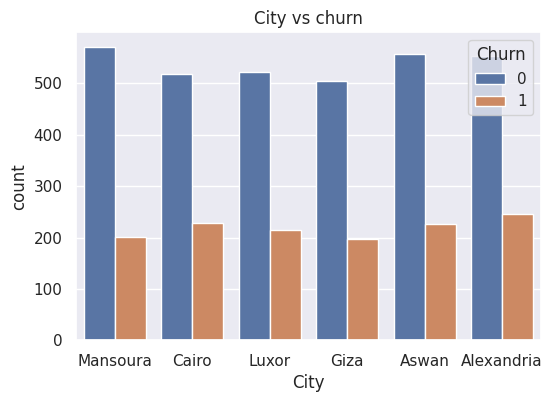

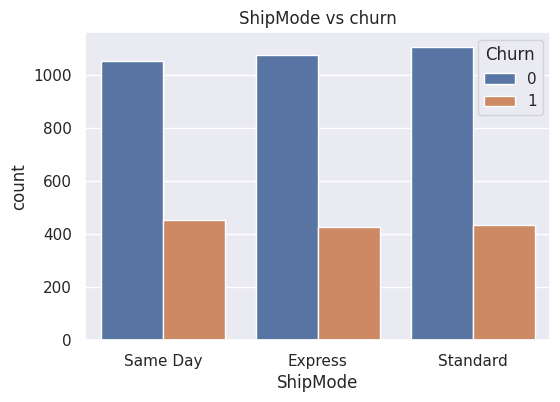

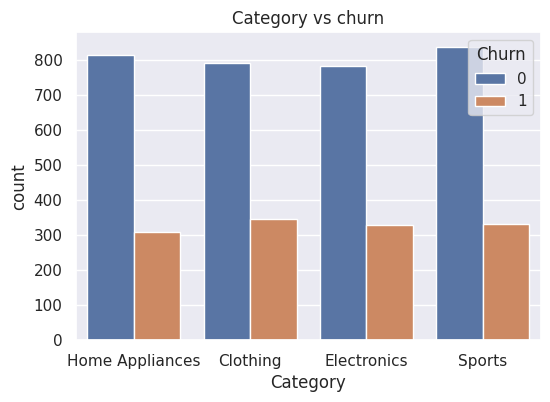

In [ ]:
cols=[
  'City',
  'ShipMode',
  'Category',
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df,x=col,hue='Churn')
    plt.title(f'{col} vs churn')
    plt.xticks(rotation=0)
    plt.show()

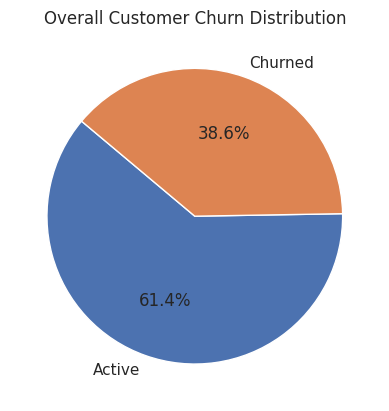

In [ ]:
customer_churn_summary = df.groupby('CustomerID')['Churn'].max().value_counts()

plt.pie(
    customer_churn_summary,
    labels=['Active', 'Churned'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Overall Customer Churn Distribution')
plt.show()
# Show the overall customer churn distribution

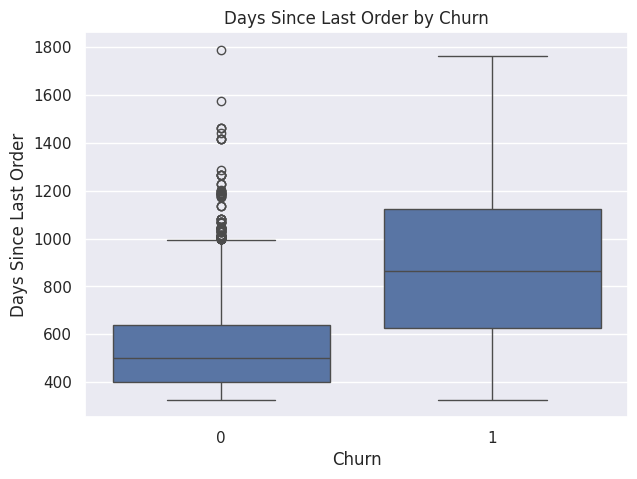

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Churn', y='Days_Since_Last_Order')

plt.title('Days Since Last Order by Churn')
plt.xlabel('Churn')
plt.ylabel('Days Since Last Order')

plt.show()
# Check if customers with more days since their last order are more likely to churn.

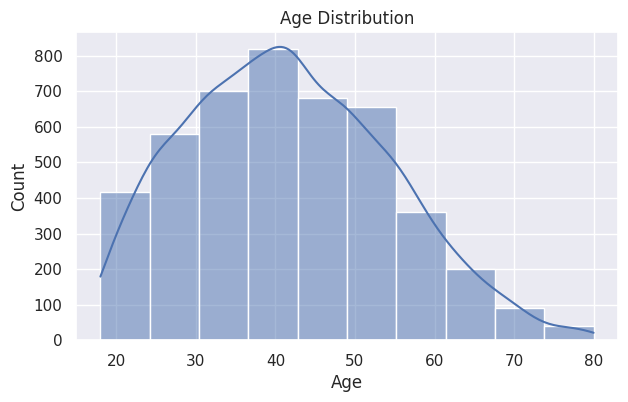

In [ ]:
plt.figure(figsize=(7,4))

sns.histplot(data=df, x='Age', bins=10, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()
# Show the distribution of customer ages

<span style="font-size: 40px;">STEP 7 : Feature Engineering </span>

<span style="font-size: 25px;">Split the data to Features and Target </span>

In [ ]:
y=df['Churn']    # y is the target that represent the column of churn
x=df.drop(['Churn'],axis=1)     # x is the features without the column of churn

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
X_train = X_train.drop(columns=['JoinDate', 'OrderDate', 'CustomerID', 'FullName', 'OrderID', 'ProductID', 'ProductName'])
X_test = X_test.drop(columns=['JoinDate', 'OrderDate', 'CustomerID', 'FullName', 'OrderID', 'ProductID', 'ProductName'])

<span style="font-size: 25px;"> Encoding </span>

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Identify remaining object columns for encoding
categorical_cols = X_train.select_dtypes(include='object').columns

for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

<span style="font-size: 25px;"> Scaling </span>

In [ ]:
from sklearn.preprocessing import StandardScaler

sc_cols = ['Age', 'Price', 'Cost', 'Quantity', 'Discount',
'Days_Since_Last_Order', 'Total_Orders']

sc=StandardScaler()

X_train[sc_cols]=sc.fit_transform(X_train[sc_cols])
X_test[sc_cols]=sc.transform(X_test[sc_cols])

<span style="font-size: 40px;">STEP 8 : Modeling </span>

<span style="font-size: 25px;">Import the Logistic Regression model from sikit_learn</span>

In [ ]:
from sklearn.linear_model import LogisticRegression

<span style="font-size: 25px;">Initialize the Logistic Regression model with a fixed randome state for reproducibility</span>

In [ ]:
model=LogisticRegression(random_state=42)

<span style="font-size: 25px;">Train the model</span>

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
model.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

<span style="font-size: 25px;">Test the model</span>

In [ ]:
y_perd = model.predict(X_test)

<span style="font-size: 25px;">Score between y_test & y_pred</span>

In [ ]:
from sklearn.metrics import accuracy_score,mean_squared_error
accuracy=accuracy_score(y_test,y_perd)
print("Accuracy : ",accuracy)

Accuracy :  0.7931793179317932


<span style="font-size: 25px;">Use joblib to save the model</span>

In [ ]:
import joblib
joblib.dump(model, "logistic_regression_model.pkl")
print("Model saved as logistic_regression_model.pkl")

Model saved as logistic_regression_model.pkl
